IMPORTS

In [11]:
import sys
import json
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["model", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from datapipeline.config import (
    ABT_FILE,
    MODEL_FILE,
    PREPROCESSOR_FILE,
    FEATURE_NAMES_FILE,
    METRICS_FILE,
    TARGET,
)

print("Raiz do projeto:", PROJECT_ROOT)

Raiz do projeto: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix


Carregar dados e artefatos

In [12]:
df = pd.read_csv(ABT_FILE)

with open(MODEL_FILE, "rb") as f:
    model = pickle.load(f)

with open(PREPROCESSOR_FILE, "rb") as f:
    preprocessor = pickle.load(f)

with open(FEATURE_NAMES_FILE, "r", encoding="utf-8") as f:
    features = json.load(f)

with open(METRICS_FILE, "r", encoding="utf-8") as f:
    saved_metrics = json.load(f)

print("ABT:", df.shape)
print("Quantidade de variáveis:", len(features))
print("AUC salva no treinamento:", saved_metrics.get("auc"))

df.head()

ABT: (307511, 21)
Quantidade de variáveis: 19
AUC salva no treinamento: 0.7118215566555474


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,IDADE,TEMPO_EMPRESA,...,PARCELA_RENDA,BEM_RENDA,RENDA_LIVRE,COMPROMETIMENTO_RENDA,PRAZO_ESTIMADO,BUREAU_QTD_CREDITOS,BUREAU_QTD_ATIVOS,BUREAU_TOTAL_CREDITO,BUREAU_TOTAL_DIVIDA,BUREAU_DEBT_RATIO
0,100002,1,202500.0,406597.5,24700.5,351000.0,Secondary / secondary special,Single / not married,25.92,1.75,...,0.12,1.73,177799.5,0.12,16.46,8.0,2.0,865055.565,245781.0,0.284122
1,100003,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,45.93,3.25,...,0.13,4.18,234301.5,0.13,36.23,4.0,1.0,1017400.500,0.0,0.000000
2,100004,0,67500.0,135000.0,6750.0,135000.0,Secondary / secondary special,Single / not married,52.18,0.62,...,0.10,2.00,60750.0,0.10,20.00,2.0,0.0,189037.800,0.0,0.000000
3,100006,0,135000.0,312682.5,29686.5,297000.0,Secondary / secondary special,Civil marriage,52.07,8.33,...,0.22,2.20,105313.5,0.22,10.53,0.0,0.0,0.000,0.0,0.000000
4,100007,0,121500.0,513000.0,21865.5,513000.0,Secondary / secondary special,Single / not married,54.61,8.32,...,0.18,4.22,99634.5,0.18,23.46,1.0,0.0,146250.000,0.0,0.000000


recriar teste

In [13]:
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_test_t = preprocessor.transform(X_test)

proba = model.predict_proba(X_test_t)[:, 1]
pred_05 = (proba >= 0.5).astype(int)

print("Teste:", X_test.shape)
print("Taxa de inadimplência no teste:", round(y_test.mean(), 4))

Teste: (61503, 19)
Taxa de inadimplência no teste: 0.0807


métricas

In [14]:
auc = roc_auc_score(y_test, proba)
precision = precision_score(y_test, pred_05, zero_division=0)
recall = recall_score(y_test, pred_05, zero_division=0)
f1 = f1_score(y_test, pred_05, zero_division=0)

print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, pred_05, zero_division=0))

AUC: 0.7118
Precision: 0.5000
Recall: 0.0006
F1-score: 0.0012

Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.50      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503



matriz de confusão

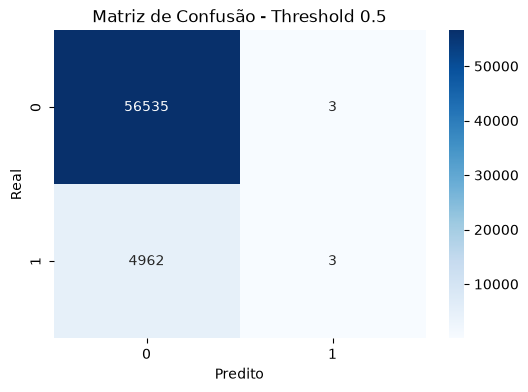

In [15]:
cm = confusion_matrix(y_test, pred_05)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Threshold 0.5")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

curva ROC

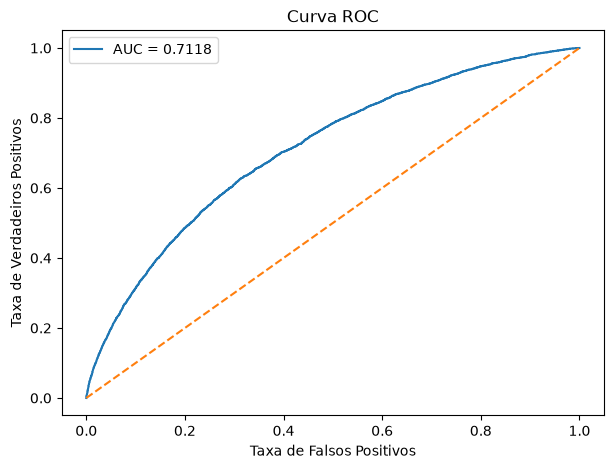

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend()
plt.show()

análise de threshold

In [17]:
threshold_list = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

rows = []

for thr in threshold_list:
    pred = (proba >= thr).astype(int)

    rows.append(
        {
            "threshold": thr,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "taxa_classificada_risco": pred.mean(),
        }
    )

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1,taxa_classificada_risco
0,0.05,0.108648,0.863646,0.193014,0.641709
1,0.10,0.166845,0.532528,0.254084,0.257662
2,0.15,0.219825,0.303726,0.255053,0.111539
3,0.20,0.272129,0.166566,0.206647,0.049412
4,0.30,0.392789,0.041692,0.075382,0.008569
5,0.40,0.492958,0.007049,0.013900,0.001154
6,0.50,0.500000,0.000604,0.001207,0.000098


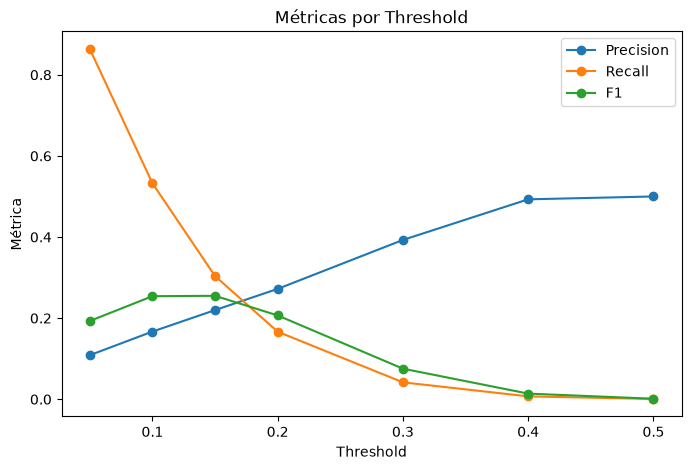

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Métricas por Threshold")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.legend()
plt.show()

importância das variáveis

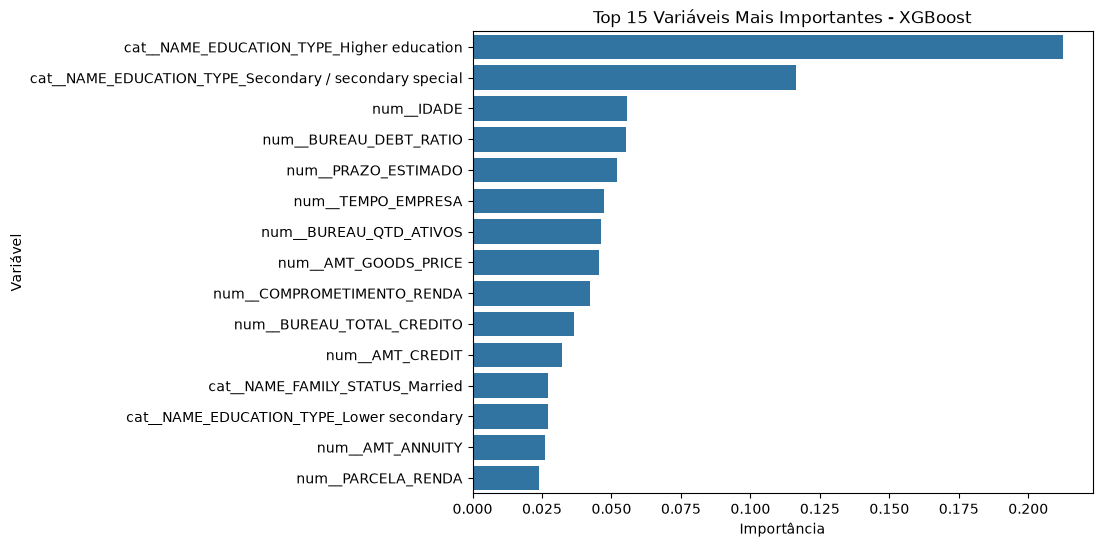

,feature,importance
18,cat__NAME_EDUCATION_TYPE_Higher education,0.212502
21,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.116419
4,num__IDADE,0.055598
16,num__BUREAU_DEBT_RATIO,0.055337
11,num__PRAZO_ESTIMADO,0.052142
5,num__TEMPO_EMPRESA,0.047439
13,num__BUREAU_QTD_ATIVOS,0.046386
3,num__AMT_GOODS_PRICE,0.045510
10,num__COMPROMETIMENTO_RENDA,0.042164
14,num__BUREAU_TOTAL_CREDITO,0.036585


In [19]:
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = [
        f"feature_{i}" for i in range(model.feature_importances_.shape[0])
    ]

importance_df = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Top 15 Variáveis Mais Importantes - XGBoost")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

importance_df

SHAP

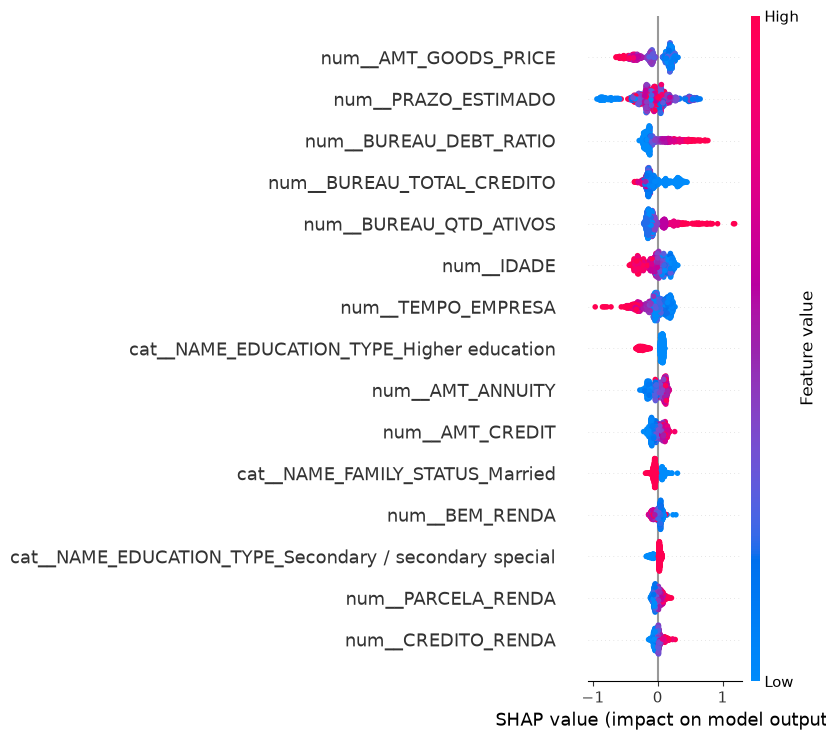

In [20]:
try:
    import shap

    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test.sample(sample_size, random_state=42)
    X_sample_t = preprocessor.transform(X_sample)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample_t)

    shap.summary_plot(
        shap_values,
        X_sample_t,
        feature_names=transformed_feature_names,
        max_display=15,
        show=True,
    )

except Exception as e:
    print("Não foi possível gerar SHAP neste ambiente.")
    print("Erro:", e)

## Conclusão

O modelo apresentou AUC próxima de 0,71, indicando capacidade razoável de separação entre clientes adimplentes e inadimplentes.

O threshold padrão de 0,5 apresentou recall baixo devido ao desbalanceamento da base.

Em produção, o threshold deveria ser calibrado conforme a estratégia de risco da empresa.

A explicabilidade pode ser acompanhada por importância de variáveis e SHAP.

As métricas salvas em `assets/metrics.json` servem como baseline para monitoramento futuro.